In [1]:
import os
import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.stats import pearsonr, kendalltau, spearmanr

from trials.utils import *

In [26]:
ground_truth_path = r'../outputs/ascadv1_variable/ground_truth_assessments/template__seed=0__window_size=5.npz'
stats_path = r'/home/jgammell/Desktop/mi_leakage_localization/outputs/ascadv1_variable/first_order_stats/stats.npy'
ll_path = r'/home/jgammell/Desktop/mi_leakage_localization/outputs/ascadv1_variable/leakage_localization_backup/seed=3/leakage_assessment.npy'

In [ ]:
stats = np.load(stats_path)
sosd = stats[1, :]
ground_truth = np.load(ground_truth_path, allow_pickle=True)['assessments'].item()
ground_truth_trace = np.mean(np.stack([x['mutinf'] for x in ground_truth.values()]), axis=0)
sosd = torch.tensor(sosd).unfold(0, 5, 1).numpy().mean(axis=-1)
ll = np.load(ll_path)
ll = torch.tensor(ll).unfold(0, 5, 1).numpy().mean(axis=-1)
print('sosd', pearsonr(sosd, ground_truth_trace).statistic, kendalltau(sosd, ground_truth_trace).statistic, spearmanr(sosd, ground_truth_trace).statistic)
print('all', pearsonr(ll, ground_truth_trace).statistic, kendalltau(ll, ground_truth_trace).statistic, spearmanr(ll, ground_truth_trace).statistic)

sosd 0.2525507928415015 0.3236045340143344
all 0.5815842101225797 0.302238763818476


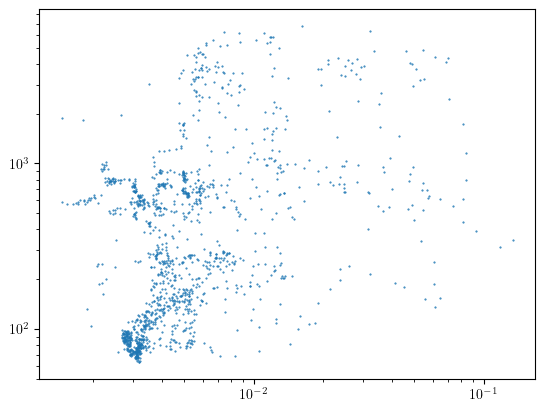

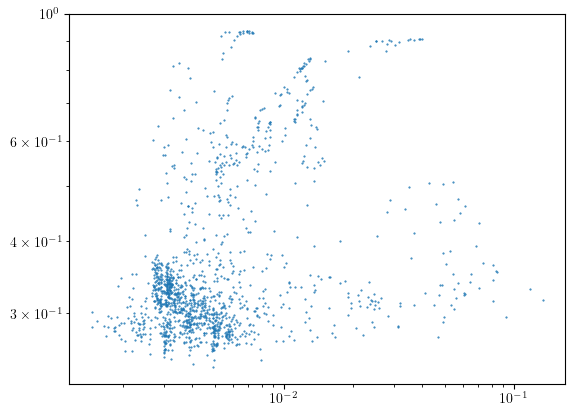

In [25]:
fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')
ax.plot(ground_truth_trace, sosd, marker='.', markersize=1, linestyle='none')

fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')
ax.plot(ground_truth_trace, ll, marker='.', markersize=1, linestyle='none')